In [ ]:
# Business Problem: To predict the price of a house based on various 
# features such as area type, location, size, etc.

# features data=  area type, location, size
# Label data = price -->check datatype(Continous data) --> Regression problem -->So use regession Algorithm

# regression Alogorithm:
# 1. Linear Alogorithm (Linear Regression)
# 2. Non Linear Regression (SVM, DT,RF, NB,KNN)

In [ ]:
# 1. Linear Alogorithm (Linear Regression)

# Implement The Linear Regression ML Models




In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# importing the dataset
import pandas as pd
df = pd.read_csv(r"clean_data_EDA.csv")
df.head()

In [ ]:
## Model Building
# 1. select the numerical columns
# 2. seprate the x/features/input and y/label/target
# 2.1 split the data into training testing
# 3. load the algorithms and create the object of algoritms
# 4. train the model --> find the pattern value from data
# 5. test then model/predict
# 6. Evaluate/Performance matrix (accuracy)
# 7. fine tuning the model(for improve accuracy)

#### 1. with only numerical columns

In [ ]:
# 1. select the numerical columns
df = df.drop(columns=["area_type","location","availability","society"], axis=1)
df.head()

In [ ]:
df.head()

In [ ]:
# 2. seprate in the x and y
X = df.drop(columns=["price"])
y = df["price"]

In [ ]:
# remove the price_per_sqft which is not nessery for model building.
X = X.drop("price_per_sqft" ,axis=1)
X

In [ ]:
y

#### 2. split the data into training testing

why do training testing split

Ans. for future use of data for predictions accuracy in unknown data

In [ ]:
# 2. split the data into training testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X ,y,test_size = 0.2,random_state =4)

print(X_train.shape)
print(X_test.shape)

In [ ]:
print(y_train.shape)
print(y_test.shape)

In [ ]:
import numpy as np
c = np.random.randint(1,10,20) # use for demonstrate the random state concept
# random state is used to get the same random number every time we run the code.
np.random.seed(42)
c

In [ ]:
# 3. load the algorithms and create the object of algoritms y=Mx+c 
from sklearn.linear_model import LinearRegression
lr = LinearRegression() #object

In [ ]:
# 4. train the model --> find the pattern value from data --> 
# find unknown value from data (y=mx + c) --> so find m,c 
lr.fit(X_train,y_train)

In [ ]:
# coffecient, intercept
print(lr.coef_)
print(lr.intercept_)

In [ ]:
# test -- > machine predictions for test data --> predicted y value
y_pred = lr.predict(X_test)
y_pred
# now we have the predicted value and actual value, we can evaluate the model performance

In [ ]:
from sklearn.metrics import r2_score
# R2score for check variance
r2_score(y_test , y_pred)

In [ ]:
# Improve the model 
#  1. add More data 
#  2. hyper parameter tuning 
#  3. change the Algorithms
#  4. Experiment 

### 2. with categorical and numerical columns with pipeline Concept

In [ ]:
# 2nd way of preprocessing in ML  --> using pipline 

In [ ]:
# import
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,LabelEncoder ,StandardScaler
from sklearn.model_selection import train_test_split # train test split

In [ ]:
df = pd.read_csv(r"clean_data_EDA.csv")
df.head()

In [ ]:
# drop unwantend columns if not need in ml traiing
df.drop(columns=['availability','society','price_per_sqft'],axis=1,inplace=True)

In [ ]:
df.head()

In [ ]:
X = df.drop(columns=["price"])
y = df["price"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# task 1 transform applying --> columns transform
columns_trans = ColumnTransformer(
    [('onehot_location', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location']),
     ('onehot_area_type', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ["area_type"]),
     ('scaler', StandardScaler(), ["total_sqft", "bath"]),
     ],
    remainder='passthrough')

# task 2 model a
lr = LinearRegression()

#pipeline
pipe = make_pipeline(columns_trans, lr)
pipe

In [ ]:
# Train the model --
pipe.fit(X_train , y_train)

In [ ]:
# Predictions the answer from machine 
y_pred = pipe.predict(X_test)
y_pred

In [ ]:
pipe.score(X_test,y_test) # accuracy of the model

# Performance Matrix
Measuring Performance metrics-Lost and Cost Function (MAE,MSE,RMSE)

In [ ]:
# cost functions --> calculate erros
from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error

print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))

https://www.mathsisfun.com/data/standard-deviation.html#WhySquare

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcT1dtwAftOd9MVE2dFRjlOLTvmqpaF63VXSfN_RP_brzgOwziqAE-I-vnI&s=10)

Choosing which metric to use depends heavily on your data (especially if it has outliers) and business priorities (how bad a huge mistake is for you). [1, 2] 
The direct breakdown of when to use MAE, MSE, or RMSE in machine learning is outlined below:
## Quick Reference Matrix

| Metric | Best Used When... | Why Use It? | Major Downside |
|---|---|---|---|
| MAE (Mean Absolute Error) | Your data has heavy noise or outliers that you want to ignore. | Highly robust to outliers; treats all errors linearly. | Harder to use directly as a mathematical loss function during optimization. |
| RMSE (Root Mean Squared Error) | You want to penalize large errors but still need the metric in interpretable units. | Reflects the cost of catastrophic errors while staying on the target scale. | Can be completely distorted by a few massive outliers. |
| MSE (Mean Squared Error) | You are mathematically tuning/optimizing your model (Loss Function). | Differentiable everywhere; smooth gradients lead to faster training convergence. | Hard to interpret because the units are squared (e.g., "$²"). |

------------------------------
## 1. Use MAE When: You want a realistic "average" error and have outliers

* 
* The Scenario: You are predicting delivery times. Most deliveries take 30 minutes, but a few take 5 hours due to rare storms. You don't want those rare storms to completely ruin your metric for everyday performance.
* Why: Because MAE does not square the errors, a single massive error won't drag the entire score down. It gives you a highly accurate reading of the model's typical, everyday behavior. [1, 2] 
* 

## 2. Use RMSE When: Large errors are absolutely unacceptable

* 
* The Scenario: You are predicting flight delays or energy grid demands. Predicting a 5-minute delay is fine, but predicting an on-time arrival when it's actually 4 hours late causes massive operational chaos.
* Why: RMSE squares the errors before taking the root. An error of 10 units adds a penalty of 100 to the math, whereas an error of 2 units only adds 4. It signals how well your model prevents worst-case scenarios while keeping the final score in the original units (e.g., minutes). [2, 3] 
* 

## 3. Use MSE When: You are writing code to train a model

* 
* The Scenario: You are writing a custom neural network or gradient descent algorithm from scratch.
* Why: Computers love MSE. The mathematical curve of a squared error function is perfectly smooth, making it incredibly easy for optimization algorithms to compute directions (gradients) to minimize errors. Note: You almost always train on MSE but report performance to humans using RMSE or MAE. [1, 4, 5, 6] 
* 

## Best Practice
Don't choose just one! Data scientists look at MAE and RMSE together. As seen in your data: [1] 

* 
* If RMSE ≈ MAE: Your model makes small, consistent errors across the board.
* If RMSE ≫ MAE: Your model is doing great on most data points but failing catastrophically on a few specific outliers. [2, 6] 
* 

To choose the right path for your specific project, tell me:

* 
* Are the outliers in your data something you want your model to actively fix/avoid, or are they flukes/bad data you want to ignore?
* If you want to dive deeper, share your R-squared value if you have it!


## Accuracy Check ,R2 Score and Adjusted R2


In [ ]:
pipe.score(X_test,y_test) # inside the score method use the formula of r2-score.

In [ ]:
# Regression Performance check using r2_score ,and Adjusted r2 score
from sklearn.metrics import r2_score
r_squared = r2_score(y_test, y_pred)
r_squared
# https://benjaminobi.medium.com/what-really-is-r2-score-in-linear-regression-20cafdf5b87c

### The R² score, also known as the coefficient of determination, is a evaluation metric used in regression analysis to measure how well a model's predictions approximate real-world data points. It quantifies the proportion of the variance in the dependent (target) variable that can be explained by the independent variables (features) in the model.

------------------------------
## 1. The Core Formula
The R² score is calculated by comparing the residual sum of squares (errors made by your model) against the total sum of squares (inherent variance of the data around its mean): [5, 6] 
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$ 
Where: [5, 7] 


* $SS_{res}$ (Residual Sum of Squares): $\sum (y_i - \hat{y}_i)^2$ — The sum of squared errors between the actual values ($y_i$) and the predicted values ($\hat{y}_i$).
* $SS_{tot}$ (Total Sum of Squares): $\sum (y_i - \bar{y})^2$ — The sum of squared differences between the actual values and the average mean (ȳ) of the data. [5, 8] 


------------------------------
## 2. How to Interpret the Value
The score typically yields a value between 0 and 1 (often expressed as 0% to 100%): [2, 9] 

* 1.0 (100%): Perfect fit. The model perfectly predicts every single data point without any error.
* 0.0 (0%): Baseline fit. The model performs no better than a simple horizontal line drawn at the average (mean) value of the data.
* Negative Value: Worse than the baseline. A negative R² occurs if the model's predictions fit the data worse than simply guessing the average value for every point. This typically happens if you apply a highly inaccurate model or omit an intercept line during linear regression fitting. [1, 2, 7, 9] 


(For example: An R² score of 0.85 means that your model accounts for 85% of the variance in the output data, leaving only 15% unexplained.) [2] 
------------------------------
## 3. Limitations & "Adjusted" R²
While popular, R² has a significant flaw: it never decreases when you add more features to your model, even if those features are completely useless noise. This can easily trick you into overfitting. [10] 
To fix this, data scientists rely on Adjusted R², which penalizes the score based on the number of predictors added:
$$\text{Adjusted } R^2 = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$$ 
(where n is the number of data points and k is the number of features) [10] 
------------------------------
## 4. Implementation in Python
You can easily calculate this metric using the r2_score function provided by the [scikit-learn library](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html): [7, 11] 

from sklearn.metrics import r2_score
# True values vs Predicted valuesy_true = [3.0, -0.5, 2.0, 7.0]y_pred = [2.5,  0.0, 2.0, 8.0]
# Calculate R2 Scorescore = r2_score(y_true, y_pred)
print(f"R2 Score: {score:.4f}")  # Output: R2 Score: 0.9486

In [ ]:
df.shape

In [ ]:
df.shape

In [ ]:
# adjusted_r2
n_samples = df.shape[0]
n_features = df.shape[1]
n_features

In [ ]:
n_samples

In [ ]:
adjusted_r2 = 1 - (1 - r_squared) * (n_samples - 1) / (n_samples - n_features - 1)
adjusted_r2
# https://www.shiksha.com/online-courses/articles/adjusted-r-squared/
# https://benjaminobi.medium.com/what-really-is-r2-score-in-linear-regression-20cafdf5b87c
# 0.586519790069246

In [ ]:
#  mx+c 
# m or c

# y=mx+c 

In [ ]:
# save the model for future use
import pickle
pickle.dump(pipe,open("model1.pkl","wb"))

In [ ]:
import sklearn
sklearn.__version__
# '1.6.1'

In [ ]:
# load the model
import pickle
model = pickle.load(open("model1.pkl","rb"))

In [44]:
d= df.sample(1)
d

,area_type,location,size,total_sqft,bath,balcony,price
12715,Built-up Area,Thanisandra,3,1694.0,3.0,1.0,125.0


In [ ]:
d=d.drop('price',axis=1)
d

In [45]:
model.predict(d)

array([104.21285392])

## Now take input from user and then predict Price

In [46]:
# # take input from user
import pandas as pd
area_type = input("Enter area type: ")
location = input("Enter location: ")
size = int(input("Enter size: "))
total_sqft = float(input("Enter total square feet: "))
bath = float(input("Enter number of bathrooms: "))
balcony = int(input("Enter number of balcony: "))

# # Create a DataFrame from user input
user_input = pd.DataFrame([[area_type, location, size, total_sqft, bath, balcony]],
                          columns=['area_type', 'location', 'size', 'total_sqft', 'bath', "balcony"])

user_input

,area_type,location,size,total_sqft,bath,balcony
0,Built-up Area,Thanisandra,4,1500.0,3.0,2


In [47]:
# # Predict the price
predicted_price = model.predict(user_input)
predicted_price


array([118.60398703])

In [48]:
print(f"The predicted price is: {predicted_price[0]:.2f} Lakhs")
# # Electronic City Phase II

The predicted price is: 118.60 Lakhs


In [ ]:
df

In [ ]:
locations = df["location"].unique()
# save the data for future use
pickle.dump(locations, open("locations.pkl","wb"))

# carpet area
carpet_area = df["area_type"].unique()
# save the data for future use
pickle.dump(carpet_area, open("area_type.pkl","wb"))

In [ ]:
# gradio 
# streamlit
# flask/fastapi/django

In [ ]:
%pip install gradio==4.44.0 huggingface_hub==0.23.0

In [ ]:
%pip install gradio

In [49]:
import gradio as gr
import pandas as pd
import pickle

# Load model
model = pickle.load(open("model1.pkl", "rb"))

# Load dropdown values
locations = pickle.load(open("locations.pkl", "rb"))
area_types = pickle.load(open("area_type.pkl", "rb"))

# 🔑 FIX: convert to Python list
locations = list(locations)
area_types = list(area_types)

def predict_price(location, area_type, size, total_sqft, bath, bhk, balcony):

    user_input = pd.DataFrame(
        [[location, area_type, size, total_sqft, bath, bhk, balcony]],
        columns=['location', 'area_type', 'size', 'total_sqft', 'bath', 'bhk', 'balcony']
    )

    predicted_price = model.predict(user_input)[0]

    return f"🏠 Estimated House Price: ₹ {predicted_price:.2f} Lakhs"


interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(choices=locations, label="Location"),
        gr.Dropdown(choices=area_types, label="Area Type"),
        gr.Number(label="Size (BHK)"),
        gr.Number(label="Total Square Feet"),
        gr.Number(label="Bathrooms"),
        gr.Number(label="Balcony"),
    ],
    outputs=gr.Textbox(label="Predicted Price"),
    title="🏡 House Price Prediction"
)

interface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


In [ ]:
# ModuleNotFoundError: No module named 'httpx'
%pip install httpx
# ModuleNotFoundError: No module named 'tqdm'
%pip install tqdm

### Save the Streamlit app code to app.py

In [ ]:
# =============================
# 🏠 House Price Prediction App (Streamlit)
# =============================

import streamlit as st
import pandas as pd
import pickle

# -----------------------------
# Page Config
# -----------------------------
st.set_page_config(
    page_title="House Price Predictor",
    page_icon="🏠",
    layout="wide"
)

# -----------------------------
# Load Model
# -----------------------------
model = pickle.load(open("model1.pkl", "rb"))

# -----------------------------
# Load Dropdown Values
# -----------------------------
locations = pickle.load(open("locations.pkl", "rb"))
area_types = pickle.load(open("area_type.pkl", "rb"))

# Convert to list
locations = list(locations)
area_types = list(area_types)

# -----------------------------
# UI Title
# -----------------------------
st.title("🏡 House Price Prediction App")
st.markdown("Enter property details to estimate price")

# -----------------------------
# Input Layout (2 Columns)
# -----------------------------
col1, col2 = st.columns(2)

with col1:
    location = st.selectbox("📍 Location", locations)
    area_type = st.selectbox("🏢 Area Type", area_types)
    size = st.number_input("📏 Size", min_value=1, step=1)

with col2:
    total_sqft = st.number_input("📐 Total Square Feet", min_value=100.0)
    bath = st.number_input("🛁 Bathrooms", min_value=1)
    bhk = st.number_input("🏠 BHK", min_value=1)
    balcony = st.number_input("🌇 Balcony", min_value=0)

# -----------------------------
# Prediction Button
# -----------------------------
if st.button("🔍 Predict Price"):

    try:
        # Create DataFrame
        user_input = pd.DataFrame(
            [[location, area_type, size, total_sqft, bath, bhk, balcony]],
            columns=['location', 'area_type', 'size', 'total_sqft', 'bath', 'bhk', 'balcony']
        )

        # Prediction
        predicted_price = model.predict(user_input)[0]

        # Output
        st.success(f"🏠 Estimated House Price: ₹ {predicted_price:.2f} Lakhs")

    except Exception as e:
        st.error(f"❌ Error: {str(e)}")

# -----------------------------
# Footer
# -----------------------------
st.markdown("---")
st.caption("Built with ❤️ using Streamlit")

In [ ]:
# steps
# 1. take all pkl files in one folder after training
# 2. create aap.py --> insert all code
# 3. create requirements.txt --> write all library which is needed to run project

In [ ]:
# For model improvement check relationship 
# and change models to improvement

In [ ]:
# Regression models --> 1. linear---> LinearRegression,OLS,SGDRegressor, ridge, lasso,eles(overfiting)
#       2. non-linear -->(Decision tree) DecisionTreeRegressor, SVR( support_vector_regression),KNNR
#               ensembles models --> RandomForestRegressor,GradientBoostingRegressor 

# classifications ---> Logistic regression(linear)
# (non-linear) SVM(SVC), KNN,naive bayes, Decision tree(classifier),RandomForestClassifer,
#       ensembles models --> all

# Deeplearning --> non-linear -Neural Network (only change in architecture for diffrent work)

### Topics
- Assumptions of Machine Learning(all ready done)
- Simple linear regression
- multiple linear regression
- variant of LR for RIDGE, LASSO ,ELASTICNET
- Measuring Performance metrics-Lost and Cost Function Model Evaluation Metrics ( MSE, MAE, RMSE)(R²-score, Adjusted R²-score)

variant of Linear models
- Polynomial Regression
- Linear Regression with OLS
- Linear Regression with SGD

- Under fitting and Overfitting
- Regularization ,Lasso & Ridge


# 1. assumption In Linear Regression (OPTIONAL / EXTRA LEARNING)

- Homoscedasticity

The variance of residuals should be approximately equal for all predicted values of the dependent variable.

- Normality - Errors are normally distributed

The residuals should be normally distributed.Linear relationship

There is a linear relationship between the dependent and independent variables

The error terms are normally distributed and the data do not contain outliers

- Independence of errors

The residual errors are independent of each other.

- No or low multicollinearity

There is no or little collinearity among input variables

#
https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/
https://www.kdnuggets.com/2021/02/machine-learning-assumptions.html

![](https://media.geeksforgeeks.org/wp-content/uploads/20241025105428904464/Assumptions-of-Linear-Regression.webp)


<!-- #### MultiColiniarity
(optional)

- What it is

Multicollinearity occurs when independent variables are correlated, which can make it difficult to estimate each variable's relationship with the outcome variable.

- Why it's a problem

Multicollinearity can negatively impact model predictions on unseen data, and can make it difficult to explain the model's behavior.

- How to detect it

A correlation matrix can help identify multicollinearity, but a heatmap of correlations can be more intuitive. A variance inflation factor (VIF) can also be used to measure the amount of multicollinearity.

- How to address it

If multicollinearity is detected, it can be addressed by using a VIF to identify the correlated variables, and then removing or transforming those variables


from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['Price'] = data.target


#multicollinearity>> when one feature is explained by all other features
#when two features>> correlation
#more than two features>> vif, clustermap

sns.heatmap(df.corr(), annot = True, vmin = -1, vmax = 1)

#clustermap table shows group(cluster ) relationship
plt.figure(figsize = (5, 5))
sns.clustermap(df.corr(), vmin = -1, vmax =1, annot = True)

### What is the function of variance_inflation_factor?
Variance Inflation Factor (VIF)

A variance inflation factor (VIF) is a measure of the amount of multicollinearity in regression analysis. Multicollinearity exists when there is a correlation between multiple independent variables in a multiple regression model. This can adversely affect the regression results.


from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Feature'] = df.columns
vif

vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

df1 = df.copy()

df1.drop("Longitude", axis=1, inplace=True)
df1
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

vif

df1.drop("AveRooms", axis=1, inplace=True)
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

df1.drop("Latitude", axis=1, inplace=True)
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

Recursive Feature Elimination (RFE) is a feature selection method that iteratively removes features and trains a model on the remaining ones, evaluating its performance at each step. By repeatedly eliminating the least important features, RFE identifies the features that contribute most to the model's accuracy. It's a valuable tool for simplifying models and improving their efficiency.

#RFE >> recruseive feature elimination
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

from sklearn.feature_selection import RFE

rfe = RFE(estimator = LinearRegression(), n_features_to_select=6)

rfe.fit(X, y)

rfe.predict(X)

rfe.support_

X.columns

rfe.ranking_

 -->
rivision codes inside this markdown

## 2. Simple Linear Regression

- y=mx +c
single feature use

## 3. Multiple Linear Regression

- multiple  feature/X use
- y =M1x1 +M2x2 + M3x3 + MnXn +c

Here are the definitions and real-world examples for each of the six assumptions of linear regression:
## 1. Linearity

* Definition: The relationship between the independent variable ($X$) and the dependent variable ($Y$) must follow a straight line.
* Example: Predicting house prices based on square footage. As square footage goes up, the price increases at a relatively constant rate. (Violation: Predicting crop yield based on fertilizer used—yield increases at first but drops off if you add too much, forming a curve).

## 2. Homoscedasticity (Equal Variance)

* Definition: The spread or variance of the residuals (the errors) must remain constant across all levels of the independent variables.
* Example: Predicting commute time based on distance traveled. The margin of error (e.g., plus or minus 5 minutes) remains roughly the same whether you travel 5 miles or 10 miles. (Violation: Predicting restaurant spending based on income. Low-income earners all spend a small, predictable amount, but high-income earners vary wildly, causing a cone-shaped error spread).

## 3. Multivariate Normality

* Definition: The residuals (errors) of the model must be normally distributed, forming a symmetrical bell curve around zero.
* Example: Predicting adult height based on genetics. Most prediction errors will be very close to zero, with a few slightly tall or slightly short outliers evenly balanced on both sides.

## 4. Independence

* Definition: The observations must be completely independent of each other, meaning the error of one data point does not influence or predict the error of the next (no autocorrelation).
* Example: Predicting house prices across random, independent neighborhoods. Knowing that one house is overpriced tells you nothing about whether the next randomly selected house will be overpriced. (Violation: Predicting stock prices day by day. If the stock drops today, it is highly likely to be low tomorrow morning).

## 5. Lack of Multicollinearity

* Definition: The independent variables ($X_1, X_2$, etc.) should not be highly correlated with each other, making it hard to tell which one is actually driving the change in $Y$.
* Example: Predicting health outcomes using age and gym attendance. These two factors are generally independent enough to measure separately. (Violation: Trying to predict weight using both "shoe size in centimeters" and "shoe size in inches" at the same time—they provide identical information).

## 6. Absence of Endogeneity

* Definition: The independent variables must not be correlated with the error term, meaning there are no hidden "omitted variables" causing a secret relationship.
* Example: Predicting ice cream sales using daily temperature. Temperature directly drives sales, independent of random daily errors. (Violation: Predicting a student's GPA using only the number of hours they study. This creates endogeneity because a hidden factor—like natural talent or access to resources—is omitted, leaking into the error term and distorting the effect of study hours).


In [50]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Generate mock data
np.random.seed(42)
X1 = np.random.randn(100)
X2 = np.random.randn(100)
# True relationship: Y = 2 + 3*X1 + 1.5*X2 + error
errors = np.random.normal(0, 1, 100)
Y = 2 + 3*X1 + 1.5*X2 + errors

# Format for statsmodels
df = pd.DataFrame({'X1': X1, 'X2': X2, 'Y': Y})
X = sm.add_constant(df[['X1', 'X2']])
model = sm.OLS(df['Y'], X).fit()

# Extract residuals and predicted values for tests
residuals = model.resid
fitted_values = model.fittedvalues


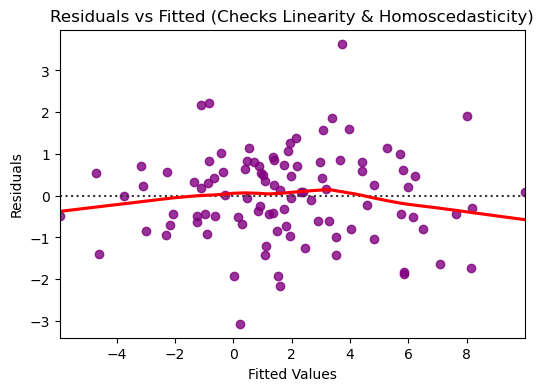

In [ ]:
# 1. Linearity & 2. Homoscedasticity (Residual Plot)
# Plotting the Residuals vs. Fitted Values tests both assumptions at once.
# • Linearity passes if the red line is flat around 0.
# • Homoscedasticity passes if the points form a random, uniform band without shaping like a cone.
plt.figure(figsize=(6, 4))
sns.residplot(x=fitted_values, y=residuals, lowess=True, color="purple", line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Checks Linearity & Homoscedasticity)')
plt.show()


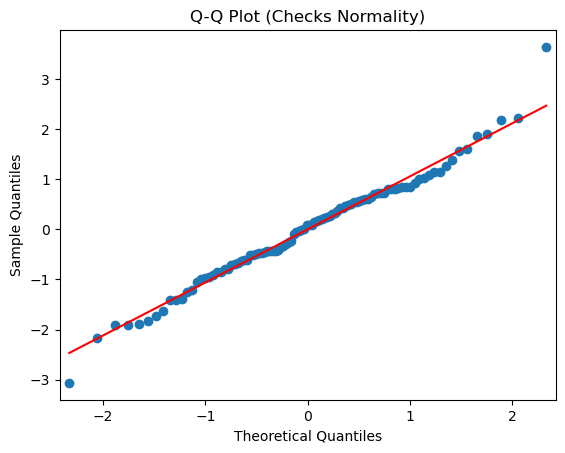

Shapiro-Wilk p-value: 0.4757 (Normal if > 0.05)


In [ ]:
# 3. Multivariate Normality (Q-Q Plot & Shapiro-Wilk)
# A Q-Q Plot visualizes normality, while the Shapiro-Wilk test gives a definitive mathematical answer. 
# If the p-value is \(>0.05\), the errors are normally distributed.
# Visual Check
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot (Checks Normality)")
plt.show()

# Statistical Test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue:.4f} (Normal if > 0.05)")


In [ ]:
# 4. Independence / Autocorrelation (Durbin-Watson)
# The Durbin-Watson statistic checks for correlation between consecutive errors.
# • A value near 2.0 means the errors are perfectly independent. Values far below 1 or above 3 signal a violation.

dw_value = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_value:.2f} (Ideal value is around 2.0)")


Durbin-Watson statistic: 2.22 (Ideal value is around 2.0)


In [ ]:
# 5. Lack of Multicollinearity (Variance Inflation Factor - VIF)
# Calculate the VIF for each predictor. A VIF value above 5 or 10 indicates high multicollinearity, 
# meaning variables are too correlated with each other.
vif_data = pd.DataFrame()
vif_data["Variable"] = df[['X1', 'X2']].columns
vif_data["VIF"] = [variance_inflation_factor(df[['X1', 'X2']].values, i) for i in range(df[['X1', 'X2']].shape[1])]
print(vif_data)


  Variable       VIF
0       X1  1.019464
1       X2  1.019464


In [ ]:
# 6. Absence of Endogeneity (Correlation Check)
# Check the correlation between each predictor 
# variable and the model's residuals. The correlation coefficients must be effectively 0.
for col in ['X1', 'X2']:
    corr, _ = stats.pearsonr(df[col], residuals)
    print(f"Correlation between {col} and Residuals: {corr:.4f} (Should be ~0)")


Correlation between X1 and Residuals: -0.0000 (Should be ~0)
Correlation between X2 and Residuals: 0.0000 (Should be ~0)
